<a href="https://colab.research.google.com/github/Amr-boot/Amr-boot/blob/master/Rock_paper_with_CNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!rm -rf /content/train_file
!rm -rf /content/test_file

In [ ]:
train_file = '/content/drive/MyDrive/Deep Learning /CNN /Rock_paper_sc/rps.zip'
test_file = '/content/drive/MyDrive/Deep Learning /CNN /Rock_paper_sc/rps-test-set.zip'

In [ ]:
!unzip -q "$train_file" -d /content/train_file
!unzip -q "$test_file" -d /content/test_file

In [ ]:
import tensorflow as tf

# The images are nested inside an 'rps' folder
train_dir = '/content/train_file/rps'

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='training',
    seed=40,
    image_size=(224, 224),
    batch_size=32
)

Found 2520 files belonging to 3 classes.
Using 2016 files for training.


In [ ]:
!ls -R /content/train_file | head -n 20

/content/train_file:
rps

/content/train_file/rps:
paper
rock
scissors

/content/train_file/rps/paper:
paper01-000.png
paper01-001.png
paper01-002.png
paper01-003.png
paper01-004.png
paper01-005.png
paper01-006.png
paper01-007.png
paper01-008.png
paper01-009.png
paper01-010.png


In [ ]:
validation_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    seed=40,
    image_size=(224, 224),
    batch_size=32
)

Found 2520 files belonging to 3 classes.
Using 504 files for validation.


In [ ]:
test_data = tf.keras.utils.image_dataset_from_directory(
    '/content/test_file/rps-test-set',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False,
    seed=40,
    label_mode='int' # Changed from 'categorical' to 'int' to match model loss
)

Found 372 files belonging to 3 classes.


In [ ]:
class_name = train_data.class_names
print(class_name)

['paper', 'rock', 'scissors']


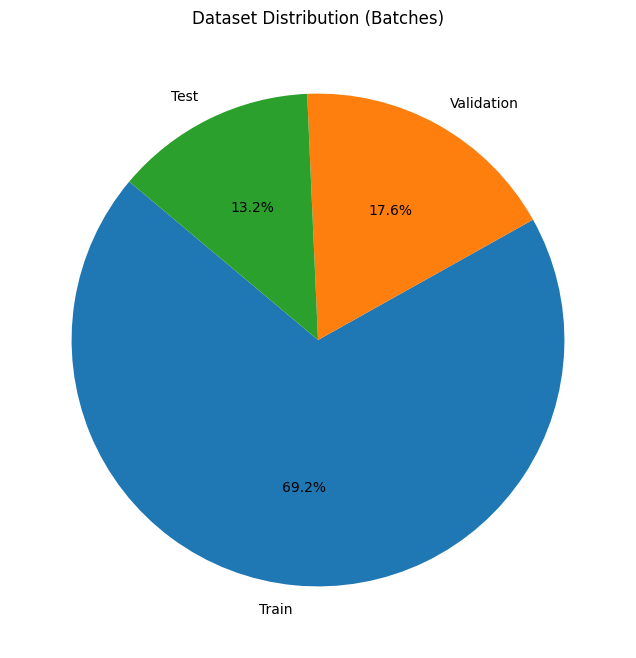

In [ ]:
# Combine lengths into a single list for the first argument
import matplotlib.pyplot as plt
data_sizes = [len(train_data), len(validation_data), len(test_data)]
labels = ['Train', 'Validation', 'Test']

plt.figure(figsize=(8, 8))
plt.pie(data_sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Dataset Distribution (Batches)')
plt.show()

Text(0.5, 1.0, 'Class Distribution')

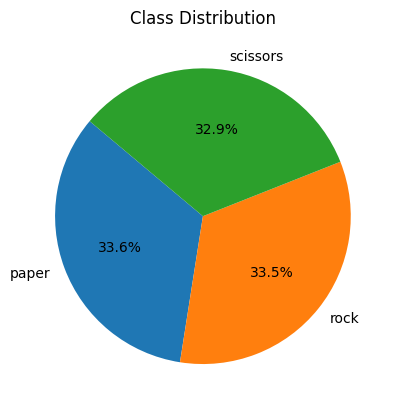

In [ ]:
import numpy as np
#class distrubtions

count_dis = np.zeros(len(class_name))
for images, labels in train_data:
    for label in labels:
        count_dis[label] += 1
plt.pie(count_dis, labels=class_name, autopct='%1.1f%%', startangle=140)
plt.title('Class Distribution')


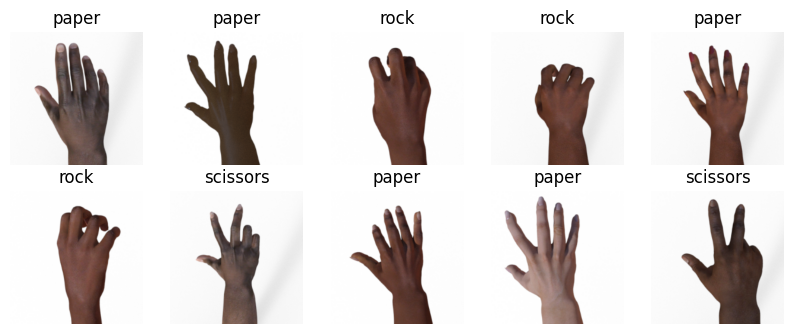

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for images, labels in train_data.take(1):
  for i in range(10):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_name[labels[i]])
    plt.axis("off")


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
from keras.regularizers import l2

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

call_back = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=0)

In [ ]:
history = model.fit(train_data, epochs=10, validation_data=validation_data, callbacks=[call_back])


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 160ms/step - accuracy: 0.7550 - loss: 0.9538 - val_accuracy: 0.9841 - val_loss: 0.3548
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.9802 - loss: 0.2952 - val_accuracy: 0.9802 - val_loss: 0.2763
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.9940 - loss: 0.2207 - val_accuracy: 1.0000 - val_loss: 0.1697
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.9960 - loss: 0.1732 - val_accuracy: 1.0000 - val_loss: 0.1476
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.9955 - loss: 0.1460 - val_accuracy: 0.9921 - val_loss: 0.1422
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.9945 - loss: 0.1510 - val_accuracy: 1.0000 - val_loss: 0.1257
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.9960 - loss: 0.1422 - val_accuracy: 1.0000 - val_loss: 0.1327


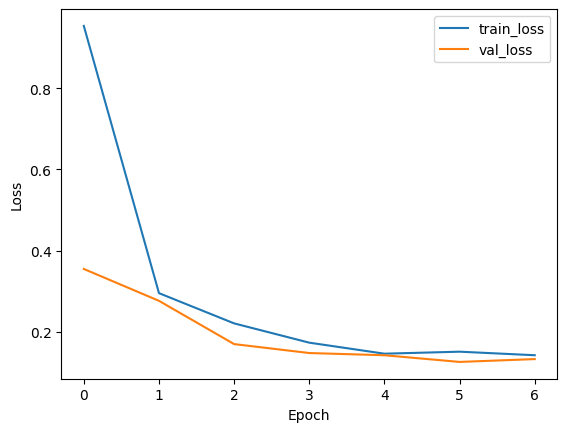

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
pred = model.predict(test_data)
pred

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step


array([[9.7817898e-01, 1.5769410e-03, 2.0244060e-02],
       [9.7683376e-01, 1.5012638e-03, 2.1665018e-02],
       [9.7323847e-01, 1.5930694e-03, 2.5168445e-02],
       ...,
       [1.0816319e-01, 5.5263925e-04, 8.9128417e-01],
       [1.0086391e-01, 5.8341847e-04, 8.9855266e-01],
       [8.8705979e-02, 5.3306023e-04, 9.1076100e-01]], dtype=float32)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
import numpy as np

# To fix the alignment issue caused by shuffle=True:
# We must iterate through the dataset ONCE to get both images and true labels together
y_true = []

for imag, labels in test_data:
  y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Get the predicted labels
y_pred = np.argmax(pred, axis=1)
y_pred
print(classification_report(y_true, y_pred, target_names=class_name))
print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted')}")
print(f"Recall: {recall_score(y_true, y_pred, average='weighted')}")



              precision    recall  f1-score   support

       paper       0.73      0.98      0.83       124
        rock       0.89      0.81      0.85       124
    scissors       0.82      0.60      0.69       124

    accuracy                           0.80       372
   macro avg       0.81      0.80      0.79       372
weighted avg       0.81      0.80      0.79       372

Accuracy: 0.7983870967741935
Precision: 0.810032655411884
Recall: 0.7983870967741935


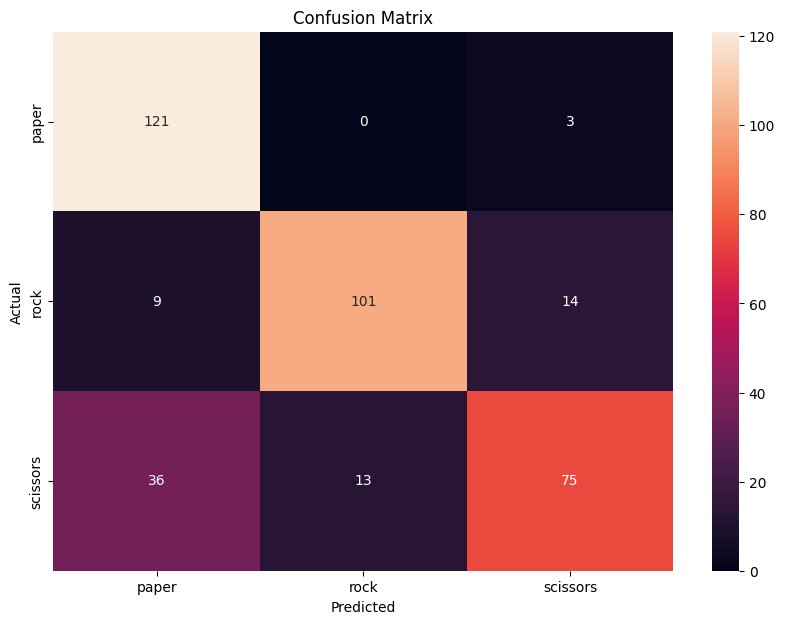

In [ ]:
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Get true labels from the test_data generator


# 2. Get predictions and convert probabilities to class indices

# 3. Create and plot the confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_name, yticklabels=class_name)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.7984 - loss: 0.8979
Test accuracy: 0.7984
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step


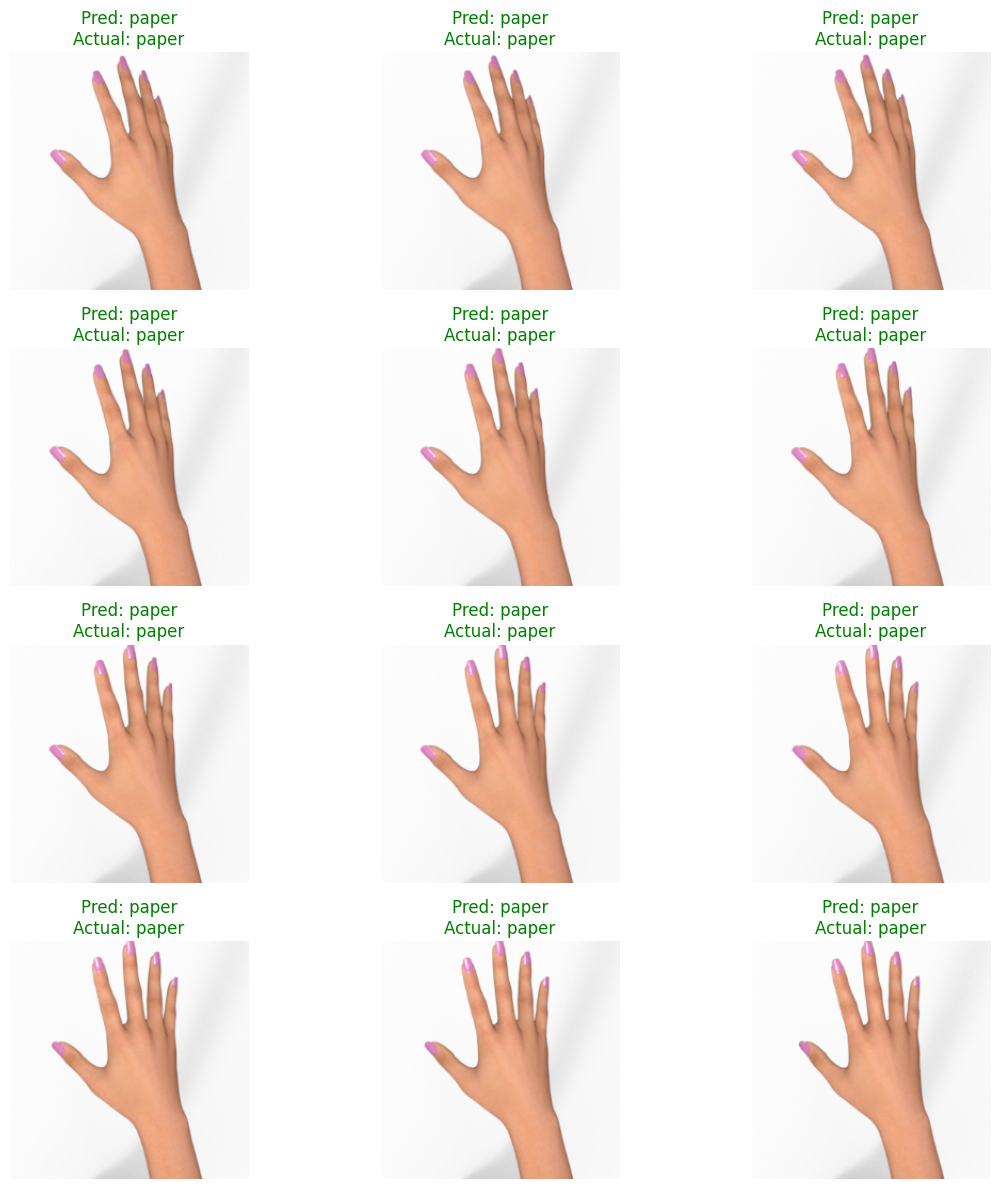

In [ ]:
import numpy as np

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_data)
print(f'Test accuracy: {test_acc:.4f}')

# Visualize predictions on a batch of test data
plt.figure(figsize=(12, 12))

# Get one batch from test_data
for images, labels in test_data.take(1):
    predictions = model.predict(images)

    for i in range(12):
        plt.subplot(4, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        # Now labels are integers, and predictions are probabilities
        predicted_class = class_name[np.argmax(predictions[i])]
        actual_class = class_name[labels[i]]

        title_color = "green" if predicted_class == actual_class else "red"
        plt.title(f"Pred: {predicted_class}\nActual: {actual_class}", color=title_color)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("rock_paper_sc.keras")


In [ ]:
model_load = tf.keras.models.load_model("rock_paper_sc.keras")

In [ ]:
loss, accuracy = model_load.evaluate(test_data)
print(f'Test accuracy: {accuracy}')
print(f"Loss {loss}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 0.7984 - loss: 0.8979
Test accuracy: 0.7983871102333069
Loss 0.8978573083877563
